Diffusers and pipeline Code

In [1]:
from diffusers import StableDiffusion3Pipeline
import torch
from config import LAM_VALUES, TSR_DIR, PT_TSR_DIR, PROMPTS_FILE, MODEL_CACHE, SEED, TSR_SIGMA, SWAP_ALGORITHM, N_INF_STEPS, GUIDANCE_SCALE

    # ── Load model once ───────────────────────────────────────────────────────────
pipe = StableDiffusion3Pipeline.from_pretrained(
	"stabilityai/stable-diffusion-3-medium-diffusers",
	torch_dtype=torch.float16,
	cache_dir=MODEL_CACHE,
)
pipe = pipe.to("cuda")
pipe.set_progress_bar_config(disable=True)

Loading pipeline components...:   0%|          | 0/9 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/219 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/517 [00:00<?, ?it/s]

Imports, configs

In [2]:
from pathlib import Path
import gc
import pandas as pd
from tqdm import tqdm
import shutil

TSR_DIR     = Path("/n/netscratch/kempner_undergrads/Everyone/zwu/parallel_toy/images/new_tsr_samples_tester")
PT_TSR_DIR  = Path("/n/netscratch/kempner_undergrads/Everyone/zwu/parallel_toy/images/new_pt_samples_tester")

REPLICA_EXCHANGE = True
LAM_VALUES = [2.0, 1.15]
INDEX_UNTIL = 20

gc.collect()
torch.cuda.empty_cache()
    

In [3]:
if PT_TSR_DIR.exists():
    shutil.rmtree(PT_TSR_DIR)


Sample!

In [4]:
# ── Load prompts once ─────────────────────────────────────────────────────────
prompts = pd.read_csv(PROMPTS_FILE, usecols=["text"], nrows=INDEX_UNTIL)["text"].tolist()
print(f"Loaded {len(prompts)} prompts")


replica_exchanges = [True, False]

lam_dirs = {}
for re in replica_exchanges:
	base = PT_TSR_DIR if re else TSR_DIR
	lam_dirs[re] = {l: base / f"lam{l:.3f}".replace(".", "p") for l in LAM_VALUES}
	for d in lam_dirs[re].values():
		d.mkdir(parents=True, exist_ok=True)

# ── Sweep ─────────────────────────────────────────────────────────────────────
for idx, prompt in enumerate(prompts):
	
	for replica_exchange in replica_exchanges:
	
		for tsr_lam in tqdm(LAM_VALUES, desc=f"idx={idx} re={replica_exchange}"):

			output_dir = lam_dirs[replica_exchange][tsr_lam]

			if (output_dir / f"{idx:05d}.png").exists():
				continue

			generator = torch.Generator(device="cuda").manual_seed(SEED)

			images = pipe(
				prompt,
				negative_prompt="",
				num_inference_steps=N_INF_STEPS,
				guidance_scale=GUIDANCE_SCALE,
				tsr_lam=tsr_lam,
				tsr_sigma=TSR_SIGMA,
				replica_exchange=replica_exchange,
				swap_algorithm=SWAP_ALGORITHM,
				generator=generator,
			).images

			out_path = output_dir / f"{idx:05d}.png"
			images[0].save(out_path, icc_profile=None)


			del images
		torch.cuda.empty_cache()

print("\n All k values complete.")

Loaded 20 prompts


idx=0 re=True:   0%|          | 0/2 [00:00<?, ?it/s]

 We tsr by 2.00 with replica exchange True
 fs 0.01524862926453352 between lams s 2.599609375 and lam t 2.0 temp s 0.3333333432674408 temp t 1.0
Time 1000.00 swap. Target 2.00 takes from source 2.599609375 ACCEPT 1.000
 fs 0.04290221631526947 between lams s 2.599609375 and lam t 2.0 temp s 0.3335581421852112 temp t 0.9987376928329468
Time 988.27 swap. Target 2.00 takes from source 2.599609375 ACCEPT 0.999
 fs 0.025908906012773514 between lams s 2.599609375 and lam t 2.0 temp s 0.3342920243740082 temp t 0.9946503043174744
Time 975.98 swap. Target 2.00 takes from source 2.599609375 ACCEPT 0.999
 fs 0.023125072941184044 between lams s 2.599609375 and lam t 2.0 temp s 0.33569449186325073 temp t 0.9869804382324219
Time 963.08 swap. Target 2.00 takes from source 2.599609375 ACCEPT 0.999
 fs 0.022460440173745155 between lams s 2.599609375 and lam t 2.0 temp s 0.33776697516441345 temp t 0.9759734869003296
Time 949.53 swap. Target 2.00 takes from source 2.599609375 ACCEPT 1.000
 fs 0.0210978481

idx=0 re=True:  50%|█████     | 1/2 [00:38<00:38, 38.26s/it]

 We tsr by 1.15 with replica exchange True
 fs 0.0 between lams s 1.4951171875 and lam t 1.150390625 temp s 0.7692307829856873 temp t 0.7692307829856873
Time 1000.00 swap. Target 1.15 takes from source 1.4951171875 ACCEPT 1.000
 fs 0.0 between lams s 1.4951171875 and lam t 1.150390625 temp s 0.7696012258529663 temp t 0.7693433165550232
Time 988.27 swap. Target 1.15 takes from source 1.4951171875 ACCEPT 1.000
 fs -5.1576498663052917e-05 between lams s 1.4951171875 and lam t 1.150390625 temp s 0.7708097696304321 temp t 0.7697097063064575
Time 975.98 swap. Target 1.15 takes from source 1.4951171875 ACCEPT 1.000
 fs -0.00015513956896029413 between lams s 1.4951171875 and lam t 1.150390625 temp s 0.7731150388717651 temp t 0.7704064249992371
Time 963.08 swap. Target 1.15 takes from source 1.4951171875 ACCEPT 1.000
 fs -0.00027023954316973686 between lams s 1.4951171875 and lam t 1.150390625 temp s 0.7765113115310669 temp t 0.7714277505874634
Time 949.53 swap. Target 1.15 takes from source 1.

...

 We tsr by 1.15 with replica exchange True
 fs 0.0 between lams s 1.4951171875 and lam t 1.150390625 temp s 0.7692307829856873 temp t 0.7692307829856873
Time 1000.00 swap. Target 1.15 takes from source 1.4951171875 ACCEPT 1.000
 fs 0.0 between lams s 1.4951171875 and lam t 1.150390625 temp s 0.7696012258529663 temp t 0.7693433165550232
Time 988.27 swap. Target 1.15 takes from source 1.4951171875 ACCEPT 1.000
 fs -3.436698898440227e-05 between lams s 1.4951171875 and lam t 1.150390625 temp s 0.7708097696304321 temp t 0.7697097063064575
Time 975.98 swap. Target 1.15 takes from source 1.4951171875 ACCEPT 1.000
 fs -7.55732980906032e-05 between lams s 1.4951171875 and lam t 1.150390625 temp s 0.7731150388717651 temp t 0.7704064249992371
Time 963.08 swap. Target 1.15 takes from source 1.4951171875 ACCEPT 1.000
 fs -0.00020089652389287949 between lams s 1.4951171875 and lam t 1.150390625 temp s 0.7765113115310669 temp t 0.7714277505874634
Time 949.53 swap. Target 1.15 takes from source 1.495

idx=4 re=True:   0%|          | 0/2 [00:00<?, ?it/s]

 We tsr by 2.00 with replica exchange True
 fs 0.017770202830433846 between lams s 2.599609375 and lam t 2.0 temp s 0.3333333432674408 temp t 1.0
Time 1000.00 swap. Target 2.00 takes from source 2.599609375 ACCEPT 1.000
 fs 0.015526863746345043 between lams s 2.599609375 and lam t 2.0 temp s 0.3335581421852112 temp t 0.9987376928329468
Time 988.27 swap. Target 2.00 takes from source 2.599609375 ACCEPT 0.998
 fs 0.016738615930080414 between lams s 2.599609375 and lam t 2.0 temp s 0.3342920243740082 temp t 0.9946503043174744
Time 975.98 swap. Target 2.00 takes from source 2.599609375 ACCEPT 1.000
 fs 0.016916655004024506 between lams s 2.599609375 and lam t 2.0 temp s 0.33569449186325073 temp t 0.9869804382324219
Time 963.08 swap. Target 2.00 takes from source 2.599609375 ACCEPT 1.000
 fs 0.017487771809101105 between lams s 2.599609375 and lam t 2.0 temp s 0.33776697516441345 temp t 0.9759734869003296
Time 949.53 swap. Target 2.00 takes from source 2.599609375 ACCEPT 1.000
 fs 0.01712339

idx=4 re=True:   0%|          | 0/2 [00:13<?, ?it/s]


KeyboardInterrupt: 

Fid computation

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

/n/home00/zoewu/.local/lib/python3.12/site-packages/torch/utils/data/dataloader.py:624: UserWarning: This DataLoader will create 12 worker processes in total. Our suggested max number of worker in current system is 1, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


Computing real image features...


100%|██████████| 1/1 [00:00<00:00,  1.37it/s]


Real features computed from 4 images.


── lam2p000 ──


...

[False]  lam=2.000  FID=311.1445  CLIP=30.5095

── lam1p150 ──


CLIP lam=1.15: 100%|██████████| 4/4 [00:00<00:00, 19.72it/s]


[True]  lam=1.150  FID=271.7676  CLIP=31.8835


CLIP lam=1.15: 100%|██████████| 4/4 [00:00<00:00, 20.25it/s]


[False]  lam=1.150  FID=306.2761  CLIP=32.1980


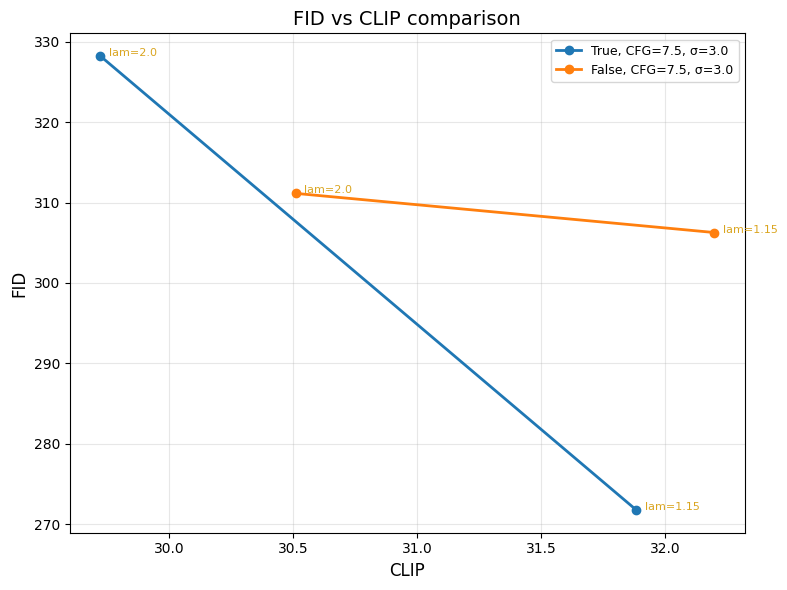

{True: {2.0: (np.float64(328.22427268541196), np.float64(29.721251487731934)),
  1.15: (np.float64(271.76762298545253), np.float64(31.883511543273926))},
 False: {2.0: (np.float64(311.144455108946), np.float64(30.509461402893066)),
  1.15: (np.float64(306.2761261442994), np.float64(32.198002338409424))}}

In [5]:
from fid import compute_sweep
# from config import LAM_VALUES, TSR_DIR, PT_TSR_DIR, PROMPTS_FILE, MODEL_CACHE, SEED, TSR_SIGMA, SWAP_ALGORITHM, N_INF_STEPS, GUIDANCE_SCALE
# INDEX_UNTIL = 100

compute_sweep(
	lam_values=LAM_VALUES,
	replica_exchanges=[True, False],
	device="cuda",
	target_indices=None,
	index_until = 4,
	pt_sr_dir = PT_TSR_DIR,
	tsr_dir = TSR_DIR,
)